<a href="https://colab.research.google.com/github/Amal-Joshy-T/ML-and-DL-Projects/blob/main/Cervical%20Cancer%20Prediction/Cervical_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📌 Problem Statement**

Cervical cancer is one of the leading causes of cancer-related deaths among women worldwide, especially in developing countries like India. Early detection significantly increases the chances of successful treatment and survival. However, traditional screening methods such as Pap smear tests and HPV testing can be time-consuming, expensive, and not easily accessible in rural areas.

The objective of this project is to develop a Machine Learning-based predictive model that can accurately classify whether a patient is at risk of cervical cancer based on medical, demographic, and behavioral factors such as age, number of sexual partners, smoking habits, contraceptive use, and medical history.

By leveraging data preprocessing techniques, handling missing values, balancing imbalanced classes (e.g., using SMOTE), and applying various Machine Learning and Deep Learning algorithms, this system aims to assist healthcare professionals in early diagnosis and decision-making.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/project data sets/cervical_cancer_70000_rows.csv')
df.head()

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,38,3.0,18.0,4.0,0.0,0.0,0.000000,1.0,10.000000,1.0,...,NaN,NaN,0,0,0,0,0,1,1,1
1,18,3.0,17.0,1.0,1.0,6.0,1.200000,0.0,0.000000,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,24,3.0,14.0,2.0,0.0,0.0,0.000000,0.0,0.000000,1.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,33,5.0,19.0,1.0,1.0,4.0,0.513202,1.0,2.282201,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
4,34,2.0,21.0,2.0,0.0,0.0,0.000000,1.0,0.330000,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 70000 non-null  int64  
 1   Number of sexual partners           67951 non-null  float64
 2   First sexual intercourse            69444 non-null  float64
 3   Num of pregnancies                  65354 non-null  float64
 4   Smokes                              68842 non-null  float64
 5   Smokes (years)                      68842 non-null  float64
 6   Smokes (packs/year)                 68842 non-null  float64
 7   Hormonal Contraceptives             61293 non-null  float64
 8   Hormonal Contraceptives (years)     61293 non-null  float64
 9   IUD                                 60479 non-null  float64
 10  IUD (years)                         60479 non-null  float64
 11  STDs                                61456

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,2049
First sexual intercourse,556
Num of pregnancies,4646
Smokes,1158
Smokes (years),1158
Smokes (packs/year),1158
Hormonal Contraceptives,8707
Hormonal Contraceptives (years),8707
IUD,9521


In [ ]:
df['Number of sexual partners'].unique()

array([ 3.,  5.,  2.,  6.,  4.,  1., nan,  8.,  7., 15.,  9., 28., 10.])

In [ ]:
df['Number of sexual partners'].fillna(df['Number of sexual partners'].median(),inplace=True)

/tmp/ipython-input-2597286035.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Number of sexual partners'].fillna(df['Number of sexual partners'].median(),inplace=True)


In [ ]:
df.fillna(df.median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
Number of sexual partners,0
First sexual intercourse,0
Num of pregnancies,0
Smokes,0
Smokes (years),0
Smokes (packs/year),0
Hormonal Contraceptives,0
Hormonal Contraceptives (years),0
IUD,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 70000 non-null  int64  
 1   Number of sexual partners           70000 non-null  float64
 2   First sexual intercourse            70000 non-null  float64
 3   Num of pregnancies                  70000 non-null  float64
 4   Smokes                              70000 non-null  float64
 5   Smokes (years)                      70000 non-null  float64
 6   Smokes (packs/year)                 70000 non-null  float64
 7   Hormonal Contraceptives             70000 non-null  float64
 8   Hormonal Contraceptives (years)     70000 non-null  float64
 9   IUD                                 70000 non-null  float64
 10  IUD (years)                         70000 non-null  float64
 11  STDs                                70000

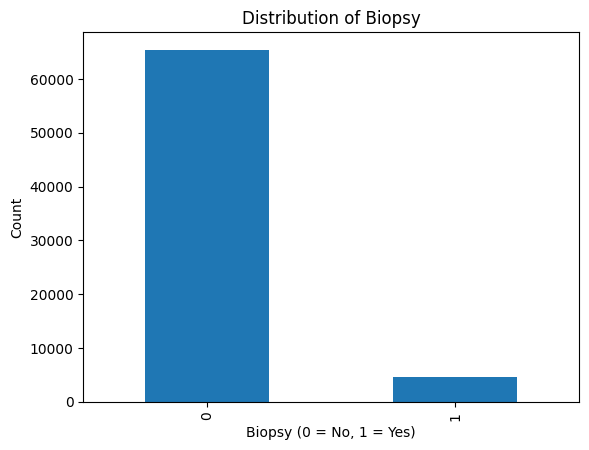

In [ ]:
plt.figure()
df['Biopsy'].value_counts().plot(kind='bar')
plt.xlabel('Biopsy (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Distribution of Biopsy')
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

# Split features and target
X = df.drop("Biopsy", axis=1)
y = df["Biopsy"]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
import pandas as pd

# Combine X_smote and y_smote into one DataFrame
df_cleaned = pd.concat([pd.DataFrame(X_smote, columns=X.columns),
     pd.Series(y_smote, name="Biopsy")],axis=1)
df=df_cleaned

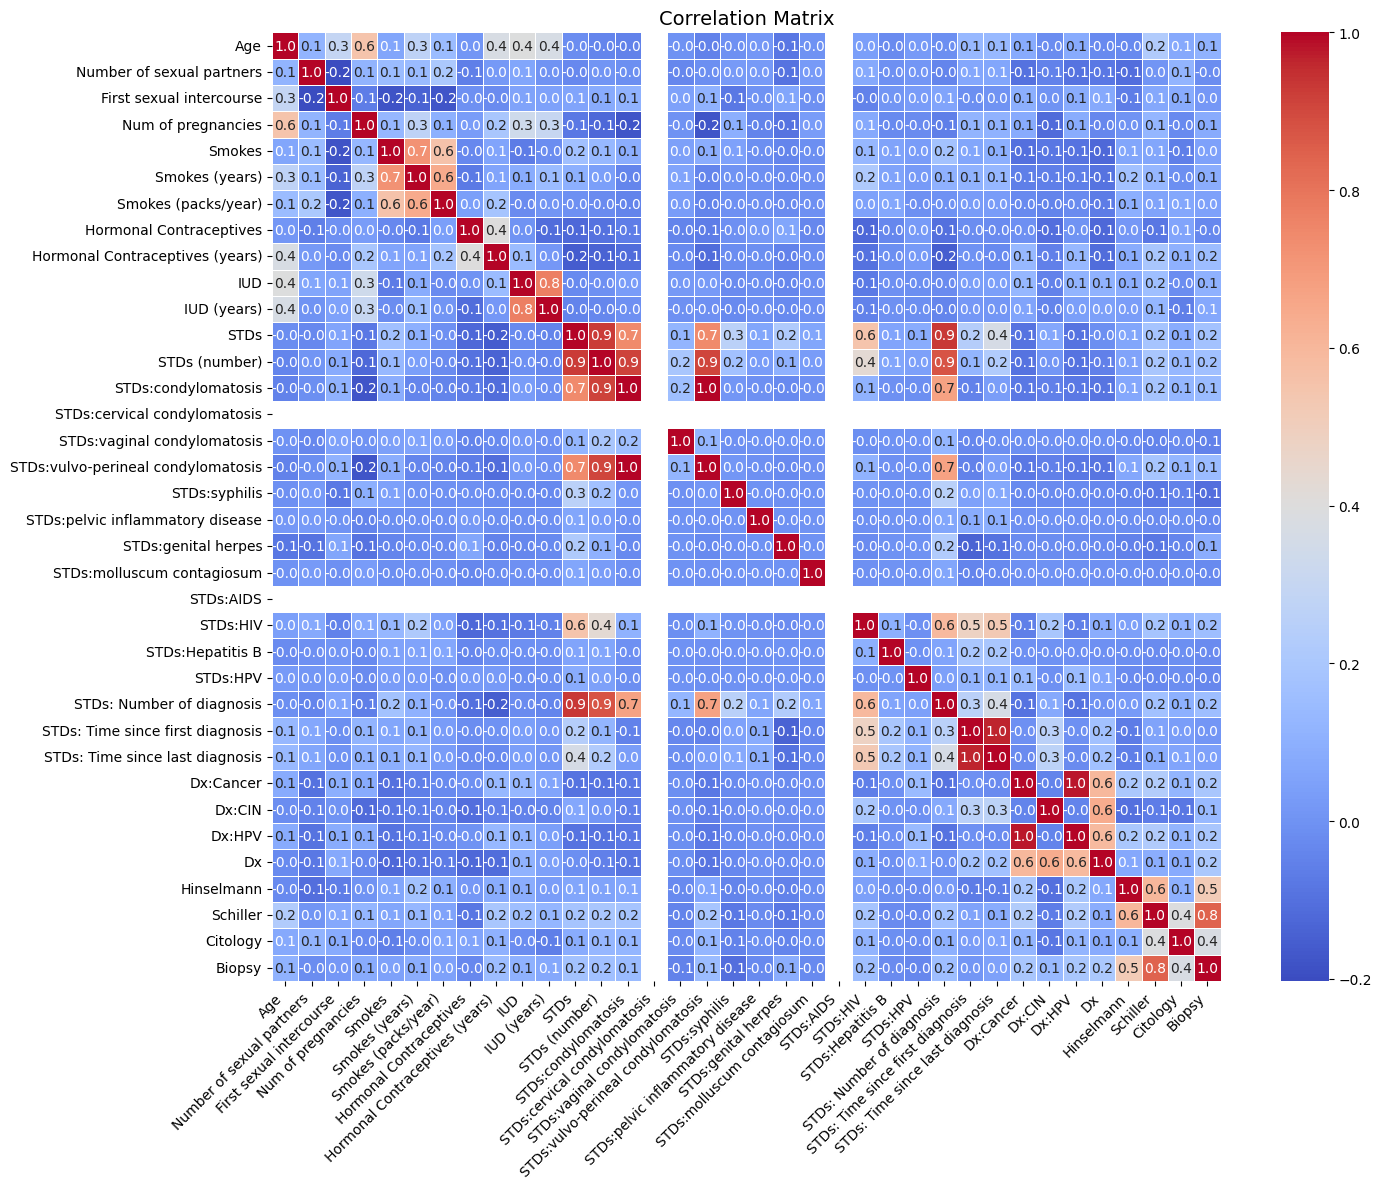

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 12))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".01f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130866 entries, 0 to 130865
Data columns (total 36 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Age                                 130866 non-null  int64  
 1   Number of sexual partners           130866 non-null  float64
 2   First sexual intercourse            130866 non-null  float64
 3   Num of pregnancies                  130866 non-null  float64
 4   Smokes                              130866 non-null  float64
 5   Smokes (years)                      130866 non-null  float64
 6   Smokes (packs/year)                 130866 non-null  float64
 7   Hormonal Contraceptives             130866 non-null  float64
 8   Hormonal Contraceptives (years)     130866 non-null  float64
 9   IUD                                 130866 non-null  float64
 10  IUD (years)                         130866 non-null  float64
 11  STDs                      

In [ ]:
df['STDs:cervical condylomatosis'].unique()

array([0.])

In [ ]:
df['STDs:AIDS'].unique()

array([0.])

In [ ]:
df.drop(['STDs:cervical condylomatosis','STDs:AIDS'],axis=1,inplace=True)

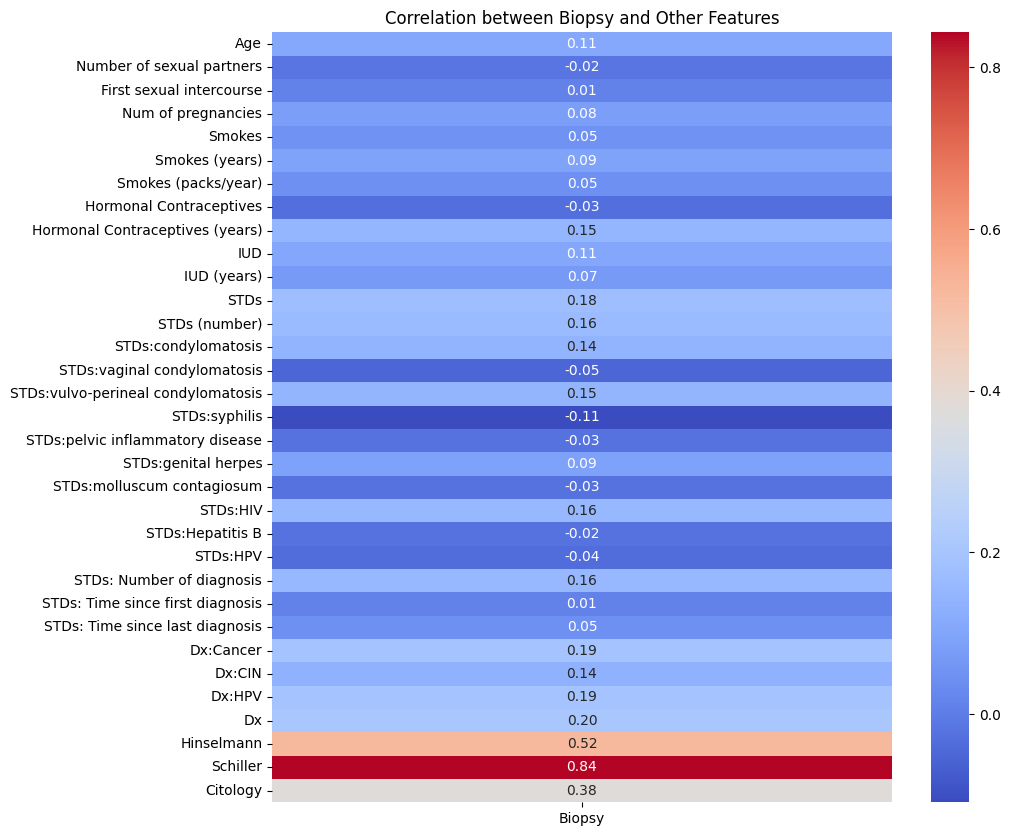

In [ ]:
HadHeartAttack_corr = df.corr()['Biopsy']


HadHeartAttack_corr = HadHeartAttack_corr.drop('Biopsy')
plt.figure(figsize=(10, 10))
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between Biopsy and Other Features')

plt.show()

In [ ]:
df = df.drop(['Age','Number of sexual partners','First sexual intercourse','Num of pregnancies','Smokes','Smokes (years)','Smokes (packs/year)',
        'Hormonal Contraceptives','IUD','IUD (years)','STDs:condylomatosis','STDs:vaginal condylomatosis','STDs:syphilis','STDs:pelvic inflammatory disease',
         'STDs:genital herpes','STDs:molluscum contagiosum','STDs:Hepatitis B','STDs:HPV','STDs: Time since first diagnosis','STDs: Time since last diagnosis',
         'Dx:CIN'],axis=1)

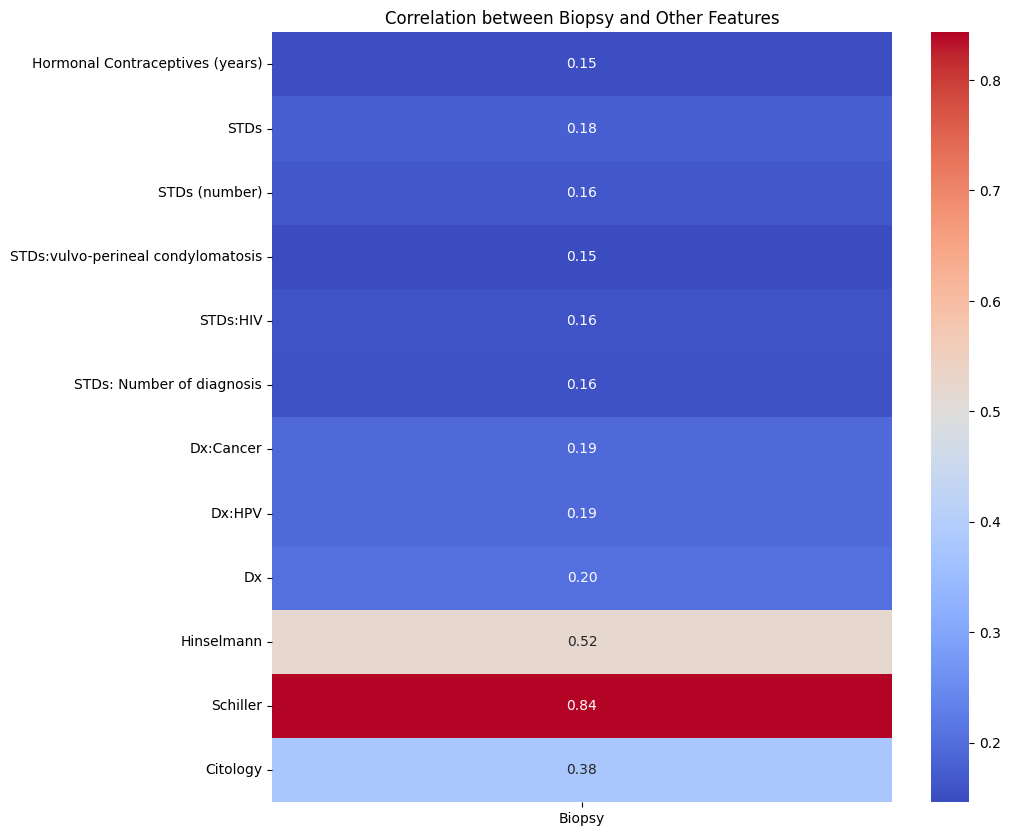

In [ ]:
HadHeartAttack_corr = df.corr()['Biopsy']


HadHeartAttack_corr = HadHeartAttack_corr.drop('Biopsy')
plt.figure(figsize=(10, 10))
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between Biopsy and Other Features')

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
X=df.drop('Biopsy',axis=1)
y=df['Biopsy']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model.score(X_test,y_test)

0.9339792768285601

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.97


In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,   # increase cache
    max_iter=5000,
    random_state=42
)

svclassifier.fit(X_train, y_train)
svclassifier.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.45966928508115046

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.97


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()

In [ ]:
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.9323308270676691
Fold 2 Accuracy: 0.9356317623326609
Fold 3 Accuracy: 0.9304315931042915
Fold 4 Accuracy: 0.9356889595305049
Fold 5 Accuracy: 0.927741777723438
Fold 6 Accuracy: 0.9337327301626116
Fold 7 Accuracy: 0.9330602763173982
Fold 8 Accuracy: 0.9335493336593715

 Best Fold: 4 with Accuracy: 0.9356889595305049


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9356889595305049

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9691893874556792

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9691893874556792

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(256,input_shape=(12,),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(best_X_train,best_y_train,epochs=60,batch_size=32)

Epoch 1/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.9349 - loss: 0.2053
Epoch 2/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9407 - loss: 0.1704
Epoch 3/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9454 - loss: 0.1466
Epoch 4/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9500 - loss: 0.1356
Epoch 5/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9536 - loss: 0.1307
Epoch 6/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9595 - loss: 0.1159
Epoch 7/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9600 - loss: 0.1115
Epoch 8/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9592 - loss: 0.1176
Epoch 9/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9606 - loss: 0.1142
Epoch 10/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9626 - loss: 0.1071
Epoch 11/60
2863/2863 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9609 - loss: 0.1102
Epoch 12/60
2863/2863 ━━

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

1227/1227 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9620 - loss: 0.1058
model accuracy:96.20%


In [ ]:
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.97


In [ ]:
X_test

,Hormonal Contraceptives (years),STDs,STDs (number),STDs:vulvo-perineal condylomatosis,STDs:HIV,STDs: Number of diagnosis,Dx:Cancer,Dx:HPV,Dx,Hinselmann,Schiller,Citology
2,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
28,6.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
36,1.0,0.0,0.0,0.0,0.0,0,0,0,0,1,1,1
37,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
55,3.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
130840,0.0,1.0,1.0,0.0,1.0,1,0,0,1,0,1,0
130843,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,1
130858,14.0,0.0,0.0,0.0,0.0,0,0,0,0,1,1,0
130861,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,1,0


In [ ]:
y_test

,Biopsy
2,0
28,0
36,0
37,0
55,0
...,...
130840,1
130843,1
130858,1
130861,1


In [ ]:
import pickle
with open("cervical forestmodel.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/cervical forestmodel.pkl","rb") as file:
  load_model=pickle.load(file)

In [ ]:
load_model.predict([[1.0,0.0,0.0,0.0,0.0,0,1,1,1,1,1,1]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

# **📌 Conclusion**

In this project, a comprehensive exploratory data analysis (EDA) was performed to understand the relationships between risk factors and cervical cancer occurrence. Missing values were handled carefully, categorical variables were encoded appropriately, and class imbalance was addressed to improve model performance.

Multiple Machine Learning models were implemented and compared, including classification algorithms, and the best-performing model achieved strong predictive accuracy. The results demonstrate that risk-factor-based predictive modeling can effectively assist in identifying high-risk individuals at an early stage.

This predictive system can support medical professionals by acting as a preliminary screening tool, reducing diagnostic delays, and potentially lowering cervical cancer mortality rates. Future improvements may include incorporating larger datasets, applying advanced deep learning architectures, and deploying the model as a real-time healthcare application.